# Laboratorium 4: Intro do modelowania statystycznego

Pracujemy na małych zbiorach referencyjnych z `scikit-learn`. Notebook jest celowo krótki i ma prowokować do dyskusji o interpretacji modeli, a nie tylko do uruchomienia gotowego kodu.


## Cele
- zbudować prosty model regresji liniowej,
- zbudować prosty model regresji logistycznej,
- policzyć podstawowe metryki jakości,
- porównać jakość modelu na zbiorze treningowym i testowym.


## Przydatne materiały
- `LinearRegression`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html
- `LogisticRegression`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- metryki regresji: https://scikit-learn.org/stable/modules/model_evaluation.html#regression-metrics
- metryki klasyfikacji: https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics
- `Pipeline`: https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html
- dodatkowe notebooki dla chętnych: `lab4_regularization.ipynb`, `lab4_thresholds_metrics.ipynb`


In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.datasets import load_breast_cancer, load_diabetes
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)


## 1. Regresja liniowa
Na początek przewidujemy wartość ciągłą. Skorzystamy ze zbioru diabetes i potraktujemy ilościowy wskaźnik progresji choroby jako zmienną docelową.


In [6]:
diabetes = load_diabetes(as_frame=True)
X_reg = diabetes.data.copy()
y_reg = diabetes.target.copy()

display(X_reg.head())
y_reg.describe()


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641


count    442.000000
mean     152.133484
std       77.093005
min       25.000000
25%       87.000000
50%      140.500000
75%      211.500000
max      346.000000
Name: target, dtype: float64

In [7]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

numeric_features = X_reg.columns.tolist()
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

reg_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
])

reg_model = Pipeline([
    ("preprocess", reg_preprocessor),
    ("model", LinearRegression()),
])

reg_model.fit(X_train_reg, y_train_reg)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [8]:
train_pred_reg = reg_model.predict(X_train_reg)
test_pred_reg = reg_model.predict(X_test_reg)

reg_metrics = pd.DataFrame({
    "split": ["train", "test"],
    "MAE": [
        mean_absolute_error(y_train_reg, train_pred_reg),
        mean_absolute_error(y_test_reg, test_pred_reg),
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_train_reg, train_pred_reg)),
        np.sqrt(mean_squared_error(y_test_reg, test_pred_reg)),
    ],
    "R2": [
        r2_score(y_train_reg, train_pred_reg),
        r2_score(y_test_reg, test_pred_reg),
    ],
})

reg_metrics


,split,MAE,RMSE,R2
0,train,43.483504,53.558843,0.527919
1,test,42.794095,53.853446,0.452603


In [9]:
coef_reg = pd.Series(
    reg_model.named_steps["model"].coef_,
    index=numeric_features,
).sort_values(key=np.abs, ascending=False)
coef_reg


s1    -44.448856
s5     35.161195
bmi    25.607121
s2     24.640954
bp     16.828872
s4     13.138784
sex   -11.511809
s3      7.676978
s6      2.351364
age     1.753758
dtype: float64

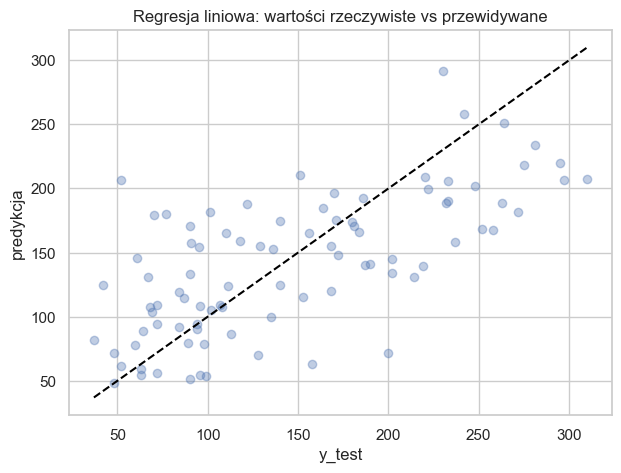

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(y_test_reg, test_pred_reg, alpha=0.35)
lims = [min(y_test_reg.min(), test_pred_reg.min()), max(y_test_reg.max(), test_pred_reg.max())]
ax.plot(lims, lims, color="black", linestyle="--")
ax.set_title("Regresja liniowa: wartości rzeczywiste vs przewidywane")
ax.set_xlabel("y_test")
ax.set_ylabel("predykcja")
plt.show()


### Pytania do dyskusji
- Czy różnica między wynikiem na train i test sugeruje niedouczenie, czy przeuczenie?
- Które cechy mają największy wpływ na predykcję?
- Czy sam model liniowy wydaje się wystarczający dla tego problemu?


## 2. Regresja logistyczna
Teraz przechodzimy do klasyfikacji binarnej. Użyjemy zbioru Breast Cancer Wisconsin i spróbujemy przewidzieć klasę nowotworu.


In [11]:
cancer = load_breast_cancer(as_frame=True)
X_cls = cancer.data.copy()
y_cls = pd.Series(cancer.target, name="target")

display(X_cls.head())
y_cls.value_counts(normalize=True).rename("share")


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


target
1    0.627417
0    0.372583
Name: share, dtype: float64

In [12]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)

cls_preprocessor = ColumnTransformer([
    ("num", numeric_transformer, X_cls.columns.tolist()),
])

cls_model = Pipeline([
    ("preprocess", cls_preprocessor),
    ("model", LogisticRegression(max_iter=2000)),
])

cls_model.fit(X_train_cls, y_train_cls)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [13]:
train_pred_cls = cls_model.predict(X_train_cls)
test_pred_cls = cls_model.predict(X_test_cls)
test_proba_cls = cls_model.predict_proba(X_test_cls)[:, 1]

cls_metrics = pd.DataFrame({
    "split": ["train", "test"],
    "accuracy": [
        accuracy_score(y_train_cls, train_pred_cls),
        accuracy_score(y_test_cls, test_pred_cls),
    ],
})
cls_metrics["roc_auc"] = [
    roc_auc_score(y_train_cls, cls_model.predict_proba(X_train_cls)[:, 1]),
    roc_auc_score(y_test_cls, test_proba_cls),
]
cls_metrics


,split,accuracy,roc_auc
0,train,0.989011,0.997482
1,test,0.982456,0.995370


In [14]:
print(classification_report(y_test_cls, test_pred_cls, target_names=cancer.target_names))


              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114



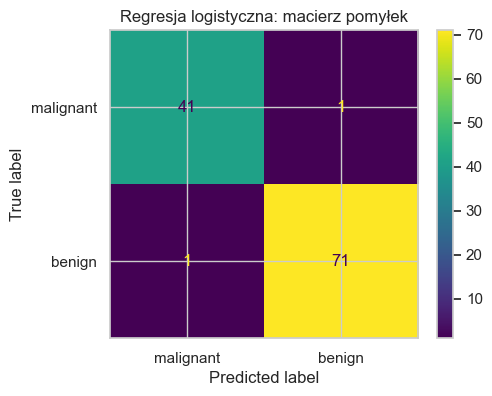

In [15]:
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(confusion_matrix(y_test_cls, test_pred_cls), display_labels=cancer.target_names).plot(ax=ax)
ax.set_title("Regresja logistyczna: macierz pomyłek")
plt.show()


In [16]:
coef_cls = pd.Series(
    cls_model.named_steps["model"].coef_[0],
    index=X_cls.columns,
).sort_values(key=np.abs, ascending=False)
coef_cls.head(10)


worst texture          -1.255088
radius error           -1.082965
worst concave points   -0.953686
worst area             -0.947756
worst radius           -0.947616
worst symmetry         -0.939181
area error             -0.929104
worst concavity        -0.823151
worst perimeter        -0.763220
worst smoothness       -0.746625
dtype: float64

### Pytania do dyskusji
- Czy accuracy wystarcza do oceny tego modelu?
- W jakiej sytuacji ROC AUC byłby ważniejszy niż accuracy?
- Jak interpretować znak i wartość współczynników w regresji logistycznej?


## 3. Zadania własne
1. Dodaj walidację krzyżową dla obu modeli.
2. Sprawdź, jak zmieniają się wyniki po usunięciu kilku cech.
3. Porównaj regresję logistyczną z innym prostym klasyfikatorem, np. `DecisionTreeClassifier`.
4. Spróbuj zbudować własny problem regresji lub klasyfikacji na danych studenckich.
